# Prompt Typo Robustness — Analysis
Exploratory companion to the README. Loads the committed raw results and reproduces the headline statistics and figures.

In [1]:
from pathlib import Path
import pandas as pd
from typo_study.analysis import (accuracy_table, fit_logit, load_results,
                                 fig_degradation, fig_typo_types, fig_heatmap)
df = load_results(Path('../results/trials.jsonl'))
df.head()

,phase,model,task,item_id,severity,typo_type,key,prompt,n_edits,response,correct,empty,latency_s,ts
0,main,llama3.2:1b,math,gsm8k-000,0.00,mixed,main|llama3.2:1b|math|gsm8k-000|0.00|mixed,Solve the following math problem. Show your re...,0,"To solve this problem, we need to calculate ho...",False,False,4.14,1.784133e+09
1,main,llama3.2:1b,math,gsm8k-000,0.05,mixed,main|llama3.2:1b|math|gsm8k-000|0.05|mixed,Solve the following math problem. Show your re...,3,"To solve this problem, we need to calculate ho...",False,False,2.12,1.784133e+09
2,main,llama3.2:1b,math,gsm8k-000,0.10,mixed,main|llama3.2:1b|math|gsm8k-000|0.10|mixed,Solve the following math problem. Show your re...,7,"To solve this problem, we need to calculate ho...",False,False,2.41,1.784133e+09
3,main,llama3.2:1b,math,gsm8k-000,0.20,mixed,main|llama3.2:1b|math|gsm8k-000|0.20|mixed,Slve the following math problem. Show yur reas...,14,"To solve this problem, we need to calculate th...",True,False,1.87,1.784133e+09
4,main,llama3.2:1b,math,gsm8k-001,0.00,mixed,main|llama3.2:1b|math|gsm8k-001|0.00|mixed,Solve the following math problem. Show your re...,0,"To solve this problem, let's break it down ste...",True,False,1.48,1.784133e+09


## Accuracy by model and severity
Wilson 95% intervals; `empty_rate` tracks refusal/format failures.

In [2]:
accuracy_table(df)

,model,severity,accuracy,ci_lo,ci_hi,empty_rate,n
0,llama3.1:8b,0.00,0.911111,0.866698,0.941722,0.0,225
1,llama3.1:8b,0.05,0.911111,0.866698,0.941722,0.0,225
2,llama3.1:8b,0.10,0.920000,0.877100,0.948799,0.0,225
3,llama3.1:8b,0.20,0.884444,0.836071,0.919911,0.0,225
4,llama3.2:1b,0.00,0.640000,0.575415,0.699884,0.0,225
5,llama3.2:1b,0.05,0.591111,0.525866,0.653297,0.0,225
6,llama3.2:1b,0.10,0.573333,0.508010,0.636195,0.0,225
7,llama3.2:1b,0.20,0.573333,0.508010,0.636195,0.0,225
8,llama3.2:3b,0.00,0.844444,0.791350,0.885975,0.0,225
9,llama3.2:3b,0.05,0.813333,0.757317,0.858830,0.0,225


## Is the degradation statistically significant?
Logistic regression with cluster-robust standard errors grouped by item (each item appears under every severity and model, so trials are not independent).

In [3]:
print(fit_logit(df))

Logistic regression, cluster-robust SEs grouped by item_id.

                           Logit Regression Results                           
Dep. Variable:                correct   No. Observations:                 3152
Model:                          Logit   Df Residuals:                     3144
Method:                           MLE   Df Model:                            7
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.1141
Time:                        16:43:37   Log-Likelihood:                -1424.6
converged:                       True   LL-Null:                       -1608.1
Covariance Type:              cluster   LLR p-value:                 2.724e-75
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            2.4131      0.239     10.115      0.000       1.945       2.881
C(mo

## Figures

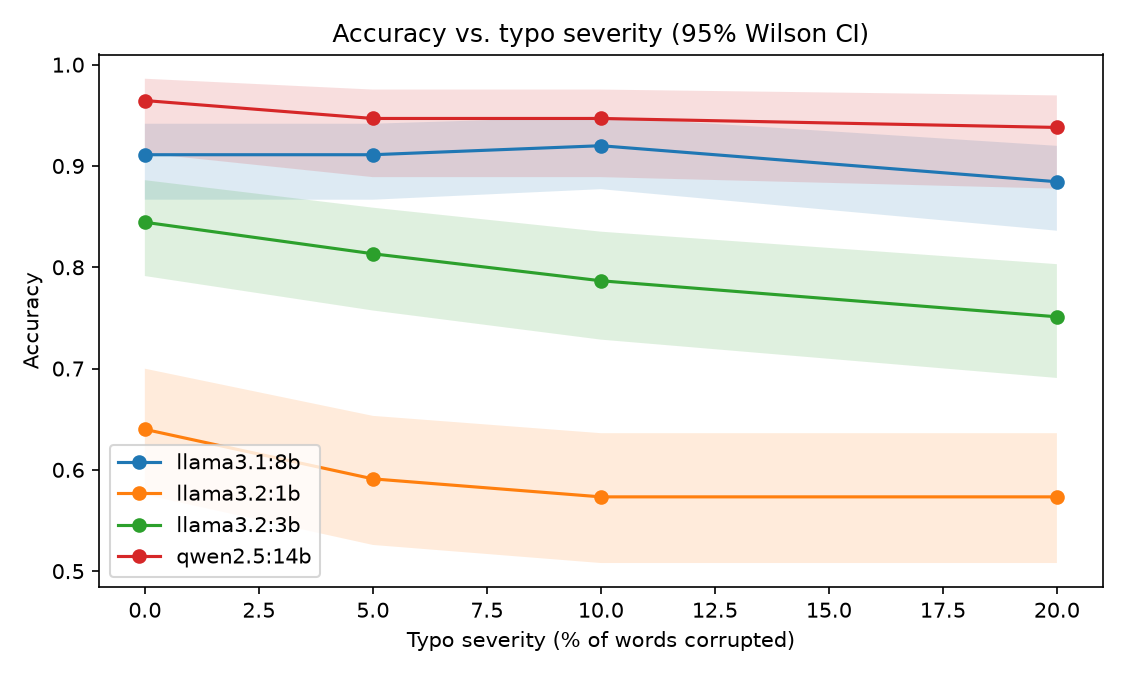

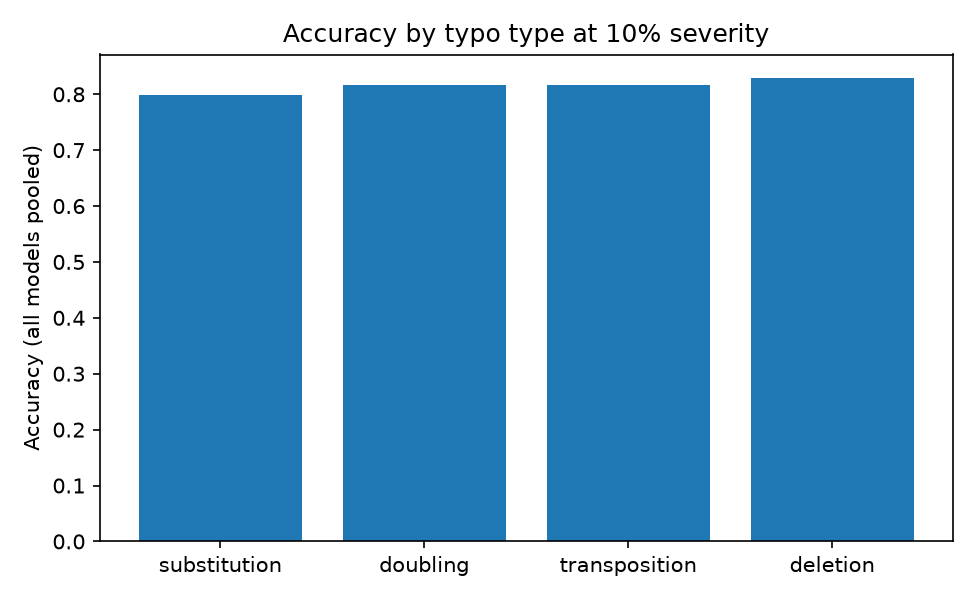

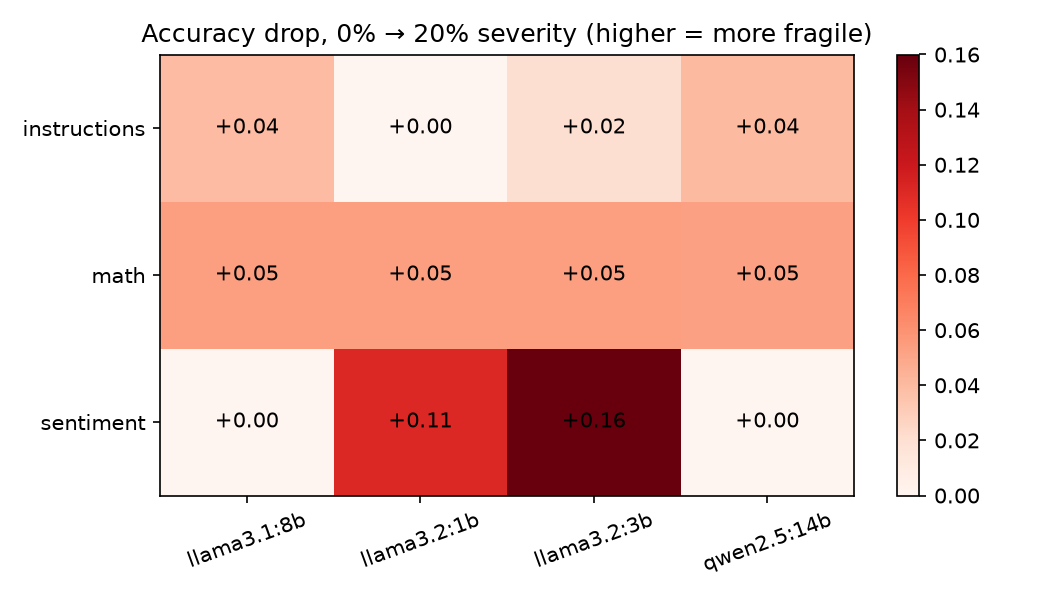

In [4]:
import tempfile
from IPython.display import Image, display
tmp = Path(tempfile.mkdtemp())
fig_degradation(df, tmp / 'deg.png')
fig_typo_types(df, tmp / 'tt.png')
fig_heatmap(df, tmp / 'hm.png')
for p in ('deg.png', 'tt.png', 'hm.png'):
    display(Image(str(tmp / p)))

## Response-length side note
Do models get more or less verbose when prompts contain typos?

In [5]:
main = df[df.phase == 'main'].copy()
main['resp_words'] = main.response.str.split().str.len()
main.groupby(['model', 'severity']).resp_words.mean().unstack().round(1)

severity,0.00,0.05,0.10,0.20
model,,,,
llama3.1:8b,52.8,55.1,53.7,52.5
llama3.2:1b,55.7,57.8,55.6,59.5
llama3.2:3b,57.4,57.5,57.2,56.6
qwen2.5:14b,65.3,62.3,62.6,60.6
